In [1]:
import numpy as np
import sys#,os
from pathlib import Path

Base_Dir = './' # assuming we are in zeldovich-smearing/examples/, else modify this
Like_Dir = Base_Dir + '../code/'
sys.path.append(Like_Dir)
from theory import TheoryManipulator

In [2]:
import matplotlib.pyplot as plt
from matplotlib import gridspec
import matplotlib as mpl
import matplotlib.colors as pltcol

mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['xtick.top'] = True
mpl.rcParams['ytick.right'] = True
mpl.rcParams['xtick.labelsize'] = 16
mpl.rcParams['ytick.labelsize'] = 16
mpl.rcParams['axes.labelsize'] = 18
mpl.rcParams['legend.fontsize'] = 16 # 14
mpl.rcParams['legend.labelspacing'] = 0.25

FS = 18
FS2 = 15
FS3 = 13
FSL = 22

mpl.rcParams['xtick.major.size'] = 6
mpl.rcParams['xtick.minor.size'] = 3
mpl.rcParams['ytick.major.size'] = 6
mpl.rcParams['ytick.minor.size'] = 3
print('mpl setup done')
#mpl.rcParams.keys()

mpl setup done


***
# BAO Multipole Models
### Theoretical exploration of Zel'dovich smearing model
***

# Basic Example

## Setup

### Configuration setup

In [3]:
Sample = 'DESI-LRG2' # one of '','DESI-LRG2' or 'Euclid-ELG'
Model_AP = True      # can be True only if Sample != ''
Include_Sig2Obs = True 
L_Max = 3

Modify_Data = True # default True
Accuracy = 'mid' # 'low','mid' or 'high'. Default 'mid', giving <~3% error on quadrupole

tm = TheoryManipulator(sample=Sample,model_AP=Model_AP,include_Sig2obs=Include_Sig2Obs,L_Max=L_Max,
                       modify_data=Modify_Data,accuracy=Accuracy,base_dir=Base_Dir)


-------------------------------------------
Theory manipulation for Zel'dovich smearing
-------------------------------------------
Setup...
... config
... files and folders
... basis functions (BiSequential instance)
... ... using 9 basis functions: [0,1,2,3,4,5,6,7,8]
... ... loading BiSequential instance
Setting up 20,6 layer feed-forward bi-neural network
... ... expecting data dim = 1, theta dim = 2, output dim = 1
... ... NNa using hidden layers of sizes [8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8]
... ... ... and activations [relu,relu,relu,relu,relu,relu,relu,relu,relu,relu,relu,relu,relu,relu,relu,tanh,tanh,tanh,tanh,tanh]
... ... NNw using hidden layers of sizes [3,3,3,3,3,9]
... ... ... and activations [tanh,tanh,tanh,tanh,tanh,tanh]
... ... using loss function 'square'
... ... not using any regularization
... ... not using any weight decay in NNa
... ... not using any weight decay in NNw
... ... extracting basis instance
... extracting basis functions from NNa
... setting up 2

### Files and folders

In [4]:
print('   Plots dir   : ',tm.plots_dir)
print(' Scales file   : ',tm.scales_file)
print('Cov mat file   : ',tm.cov_file)
print('   Data file(s): ',tm.data_file)

   Plots dir   :  ./plots/AbacusSummit/base_c000/DESI-LRG2/
 Scales file   :  ./data/AbacusSummit/base_c000/DESI-LRG2/xi_LMax3_lgMmin12.90_z0.800_scales.txt
Cov mat file   :  ./data/AbacusSummit/base_c000/DESI-LRG2/covmat_LMax3_lgMmin12.90_z0.800_inclSig2obs_AP.txt
   Data file(s):  ['./data/AbacusSummit/base_c000/DESI-LRG2/Sig2obs_LMax3_lgMmin12.90_z0.800.txt', './data/AbacusSummit/base_c000/DESI-LRG2/xi_LMax3_lgMmin12.90_z0.800.txt']


### Fiducial values
( Based on ground truth for cosmology and MCMC analysis for sdbmc )

In [5]:
xilin_true = tm.load_xilin(tm.fiducial['growth'][tm.sample])

print('---------------')
print('Fiducial values')
print('---------------')
for key in tm.fiducial.keys():
    if np.isscalar(tm.fiducial[key]):
        value = tm.fiducial[key]
    else:
        value = tm.fiducial[key][tm.sample]
    print(key+': {0:.3e}'.format(value))
print('---------------')
print('Params list:',tm.params_list)
print('---------------')
print(' Latex list:',tm.latex_list)
print('---------------')

---------------
Fiducial values
---------------
f: 8.389e-01
growth: 6.648e-01
sigv: 3.870e+00
Daiso: 6.910e-04
DaAP: -5.939e-04
fv: 2.600e-01
rLP: 9.304e+01
rZC: 1.206e+02
w_0: 5.925e-03
w_1: -1.205e-02
w_2: -9.072e-03
w_3: 1.600e-02
w_4: 6.265e-03
w_5: 1.796e-02
w_6: -1.719e-02
w_7: 6.749e-03
w_8: 1.829e-02
b: 2.383e+00
B1st: -1.229e+00
Bvst: 8.760e+00
AMC: 2.406e-02
sigma: 7.362e+00
beta: 3.520e-01
qbar2: 5.637e-02
qbar4: 0.000e+00
---------------
Params list: ['beta', 'sigv', 'w_0', 'w_1', 'w_2', 'w_3', 'w_4', 'w_5', 'w_6', 'w_7', 'w_8', 'b', 'B1st', 'Bvst', 'sigma', 'AMC', 'qbar2', 'qbar4', 'fv', 'Daiso', 'DaAP']
---------------
 Latex list: ['\\beta', '\\sigma_{\\rm v}', 'w_0', 'w_1', 'w_2', 'w_3', 'w_4', 'w_5', 'w_6', 'w_7', 'w_8', 'b', 'B_{1\\ast}', 'B_{v\\ast}', '\\sigma', 'A_{\\rm MC}', '\\bar q^{(2)}', '\\bar q^{(4)}', 'f_{\\rm v}', '\\Delta\\alpha_{\\rm iso}', '\\Delta\\alpha_{\\rm AP}']
---------------


### Basis functions

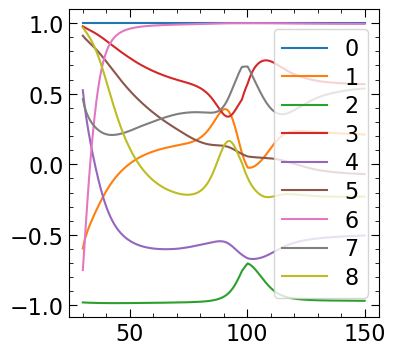

In [6]:
rvals = np.linspace(30,150,500)
basis_func = tm.load_basis_func(rvals)

plt.figure(figsize=(4,4))
for b in range(tm.n_basis):
    plt.plot(rvals,basis_func[b],label=str(tm.use_basis[b]))
plt.minorticks_on()
plt.legend()
plt.show()

## Model evaluation

### Evaluation dictionary

In [7]:
Eval_Dict = {}
for key in tm.params_list:
    if np.isscalar(tm.fiducial[key]):
        value = tm.fiducial[key]
    else:
        value = tm.fiducial[key][tm.sample]
    Eval_Dict[key] = value
# Eval_Dict

### Evaluate!

In [8]:
prediction = tm.calc_model(Eval_Dict) # default wrap=True
prediction_flat = tm.calc_model(Eval_Dict,wrap=False)
# print(prediction_flat)

## Data

### Load data

In [9]:
data,cov_data = tm.load_data()
data_flat,cov_data = tm.load_data(wrap=False)
# print(data_flat)

### Compare model

In [10]:
# compare data with model
chi2 = tm.calc_chi2(data_flat,prediction_flat)
print('chi2: {0:.1f}'.format(chi2))

chi2: 187.7


## Plots

### Basic comparison

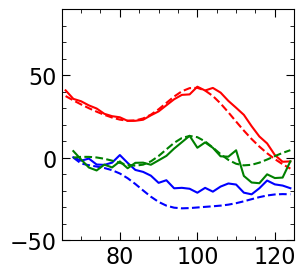

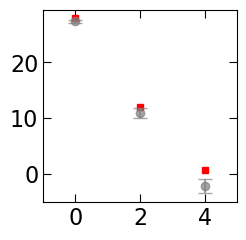

In [11]:
plt.figure(figsize=(3,3))
plt.xlim(65,125)
if Modify_Data:
    plt.ylim(-50,90)
else:
    plt.ylim(-120,120)
off = 1 if Modify_Data else 0
offset = 1 if Include_Sig2Obs else 0
plt.plot(tm.theory.svals,tm.theory.svals**2*data[offset],'r-')
plt.plot(tm.theory.svals,tm.theory.svals**2*prediction[offset],'r--')
if L_Max > 1:
    plt.plot(tm.theory.svals[off:],tm.theory.svals[off:]**2*data[offset+1],'b-')
    plt.plot(tm.theory.svals[off:],tm.theory.svals[off:]**2*prediction[offset+1],'b--')
    if L_Max == 3:
        plt.plot(tm.theory.svals[off:],tm.theory.svals[off:]**2*data[offset+2],'g-')
        plt.plot(tm.theory.svals[off:],tm.theory.svals[off:]**2*prediction[offset+2],'g--')
plt.minorticks_on()
plt.show()

if Include_Sig2Obs:
    Sigx = np.array([2*L for L in range(L_Max)])
    plt.figure(figsize=(2.5,2.5))
    plt.xlim(-1,2*L_Max-1)
    plt.xticks(Sigx)
    plt.plot(Sigx,prediction[0],'r',marker='s',ls='none',markersize=4)
    plt.errorbar(Sigx,data[0],yerr=np.sqrt(np.diag(cov_data)[:L_Max]),capsize=5,marker='o',c='gray',ls='none',alpha=0.7)
    plt.show()

In [12]:
tm.theory.svals

array([ 66.,  68.,  70.,  72.,  74.,  76.,  78.,  80.,  82.,  84.,  86.,
        88.,  90.,  92.,  94.,  96.,  98., 100., 102., 104., 106., 108.,
       110., 112., 114., 116., 118., 120., 122., 124.])

### Auxiliary functions

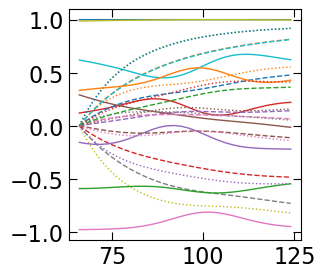

In [13]:
# calculate and plot smoothed basis \lambda_m, \bar \lambda_m, \bar\bar \lambda_m
lam = tm.theory.calc_lambda(Eval_Dict['sigma'])
if L_Max > 1:
    lam_b,lam_bb = tm.theory.calc_lambda_bars(Eval_Dict['sigma'])
plt.figure(figsize=(3,3))
for b in range(tm.n_basis):
    plt.plot(tm.theory.svals,lam[b],lw=1,ls='-',label=str(tm.use_basis[b]))
    if L_Max > 1:
        plt.plot(tm.theory.svals,lam_b[b],lw=1,ls='--')
        if L_Max == 3:
            plt.plot(tm.theory.svals,lam_bb[b],lw=1,ls=':')
# plt.legend()
plt.show()